In [2]:
# Step 1: Load Datasets and Perform Strict Patient Barcode Matching

import pandas as pd
import numpy as np

df_mut = pd.read_csv("data_mutations.txt", sep='\t', comment='#', low_memory=False)
df_rna = pd.read_csv("data_mrna_seq_v2_rsem.txt", sep='\t', comment='#', low_memory=False)

df_mut['Patient_ID'] = df_mut['Tumor_Sample_Barcode'].str.slice(0, 12)

rna_samples = [col for col in df_rna.columns if col.startswith("TCGA")]
rna_patient_map = {col: col[:12] for col in rna_samples}

mut_patients = set(df_mut['Patient_ID'])
rna_patients = set(rna_patient_map.values())
overlap_patients = mut_patients.intersection(rna_patients)

print(f"Total Unique Patients in Mutation Data: {len(mut_patients)}")
print(f"Total Unique Patients in RNA-Seq Data: {len(rna_patients)}")
print(f"Exact Overlapping Unique Patients: {len(overlap_patients)}")

Total Unique Patients in Mutation Data: 281
Total Unique Patients in RNA-Seq Data: 294
Exact Overlapping Unique Patients: 278


In [3]:
# Step 2: Filter Overlapping Cohorts and Define Helical Hotspot vs Wild-Type Groups

overlapping_patients_list = sorted(list(overlap_patients))

pik3ca_muts = df_mut[(df_mut['Patient_ID'].isin(overlapping_patients_list)) &
                     (df_mut['Hugo_Symbol'] == 'PIK3CA')]

helical_hotspots = ['p.E542K', 'p.E545K']
helical_mut_patients = set(pik3ca_muts[pik3ca_muts['HGVSp_Short'].isin(helical_hotspots)]['Patient_ID'])

all_pik3ca_mut_patients = set(pik3ca_muts['Patient_ID'])

wildtype_patients = set(overlapping_patients_list) - all_pik3ca_mut_patients


print(f"1. Total PIK3CA Mutated Patients (Any domain): {len(all_pik3ca_mut_patients)}")
print(f"2. Helical Domain Hotspot Mutated Patients (E542K/E545K): {len(helical_mut_patients)}")
print(f"3. PIK3CA Wild-Type Patients: {len(wildtype_patients)}")

1. Total PIK3CA Mutated Patients (Any domain): 82
2. Helical Domain Hotspot Mutated Patients (E542K/E545K): 58
3. PIK3CA Wild-Type Patients: 196


In [4]:
# Step 3: Quantify Top Driver Mutations and Cohort Breakdown

common_patients = sorted(list(overlap_patients))
df_mut_filtered = df_mut[df_mut['Patient_ID'].isin(common_patients)].copy()

patient_gene_mut_counts = df_mut_filtered.groupby('Hugo_Symbol')['Patient_ID'].nunique().sort_values(ascending=False)

print("Top 10 Mutated Genes by UNIQUE PATIENT COUNT (out of 278)")
print(patient_gene_mut_counts.head(10))

pik3ca_mut_patients = set(df_mut_filtered[df_mut_filtered['Hugo_Symbol'] == 'PIK3CA']['Patient_ID'])

helical_hotspots = ['p.E542K', 'p.E545K']
helical_mut_patients = set(df_mut_filtered[
    (df_mut_filtered['Hugo_Symbol'] == 'PIK3CA') &
    (df_mut_filtered['HGVSp_Short'].isin(helical_hotspots))
]['Patient_ID'])

wildtype_patients = set(common_patients) - pik3ca_mut_patients


print(f"Total Matched Patients: {len(common_patients)}")
print(f"Total PIK3CA Mutated Patients (All domains): {len(pik3ca_mut_patients)}")
print(f"PIK3CA Helical Domain Mutated Patients (E542K/E545K): {len(helical_mut_patients)}")
print(f"PIK3CA Wild-Type Patients: {len(wildtype_patients)}")

Top 10 Mutated Genes by UNIQUE PATIENT COUNT (out of 278)
Hugo_Symbol
TTN       115
PIK3CA     82
MUC16      57
MUC4       56
KMT2C      56
KMT2D      49
SYNE1      46
DMD        44
RYR2       42
DST        42
Name: Patient_ID, dtype: int64
Total Matched Patients: 278
Total PIK3CA Mutated Patients (All domains): 82
PIK3CA Helical Domain Mutated Patients (E542K/E545K): 58
PIK3CA Wild-Type Patients: 196


In [5]:
# Step 4: Analyze PIK3CA Mutation Types and Specific Amino Acid Changes

pik3ca_muts = df_mut_filtered[df_mut_filtered['Hugo_Symbol'] == 'PIK3CA']

print("PIK3CA Mutation Types (Structural Effects) ")
print(pik3ca_muts['Variant_Classification'].value_counts())

print("\n Top Specific Protein Changes (HGVSp_Short) ")
print(pik3ca_muts['HGVSp_Short'].value_counts().head(5))

PIK3CA Mutation Types (Structural Effects) 
Variant_Classification
Missense_Mutation    96
3'UTR                 1
Name: count, dtype: int64

 Top Specific Protein Changes (HGVSp_Short) 
HGVSp_Short
p.E545K     37
p.E542K     22
p.E726K      6
p.H1047R     2
p.E453K      2
Name: count, dtype: int64


In [6]:
# Step 5: Differential Gene Expression Analysis using Welch's t-test and BH-FDR Correction

import pandas as pd
import numpy as np
from scipy import stats

rna_sample_cols = [c for c in df_rna.columns if c.startswith("TCGA")]

helical_rna_cols = []
wt_rna_cols = []

for col in rna_sample_cols:
    patient_id = col[:12]
    if patient_id in helical_mut_patients:
        helical_rna_cols.append(col)
    elif patient_id in wildtype_patients:
        wt_rna_cols.append(col)

print(f"RNA-seq Columns Selected -> Helical Mutated: {len(helical_rna_cols)}, Wild-Type: {len(wt_rna_cols)}")

dge_results = []
df_rna_clean = df_rna.dropna(subset=['Hugo_Symbol']).copy()

for idx, row in df_rna_clean.iterrows():
    gene = row['Hugo_Symbol']

    h_vals = row[helical_rna_cols].values.astype(float)
    w_vals = row[wt_rna_cols].values.astype(float)

    h_mean = np.mean(h_vals)
    w_mean = np.mean(w_vals)

    log2fc = np.log2(h_mean + 1) - np.log2(w_mean + 1)

    stat, pval = stats.ttest_ind(h_vals, w_vals, equal_var=False)

    dge_results.append({
        'Gene': gene,
        'Helical_Mut_Mean': round(h_mean, 2),
        'WT_Mean': round(w_mean, 2),
        'Log2FC': round(log2fc, 4),
        'P_Value': pval
    })

df_dge = pd.DataFrame(dge_results).dropna(subset=['P_Value'])

df_dge['FDR'] = stats.false_discovery_control(df_dge['P_Value'])

def assign_status(row):
    if row['FDR'] < 0.05 and row['Log2FC'] > 0.5:
        return 'Up-regulated'
    elif row['FDR'] < 0.05 and row['Log2FC'] < -0.5:
        return 'Down-regulated'
    else:
        return 'Not Significant'

df_dge['Status'] = df_dge.apply(assign_status, axis=1)

sig_degs = df_dge[df_dge['Status'] != 'Not Significant'].sort_values('P_Value')
print(f"Total Significant DEGs (FDR < 0.05, |Log2FC| > 0.5): {len(sig_degs)}")

print("\n TOP DOWN-REGULATED DEGs (Table 1 Validation) ")
print(sig_degs[sig_degs['Status'] == 'Down-regulated'][['Gene', 'Helical_Mut_Mean', 'WT_Mean', 'Log2FC', 'P_Value', 'FDR', 'Status']].head(10).to_string(index=False))

sig_degs.to_csv("significant_degs.csv", index=False)

RNA-seq Columns Selected -> Helical Mutated: 58, Wild-Type: 196
Total Significant DEGs (FDR < 0.05, |Log2FC| > 0.5): 181

 TOP DOWN-REGULATED DEGs (Table 1 Validation) 
     Gene  Helical_Mut_Mean  WT_Mean  Log2FC      P_Value      FDR         Status
   HSF2BP             21.95    45.16 -1.0081 1.184505e-09 0.000024 Down-regulated
  SNORD1C             26.90    42.39 -0.6370 2.400803e-08 0.000186 Down-regulated
C14orf149             55.92    86.63 -0.6224 3.011056e-08 0.000186 Down-regulated
  C1QTNF6            417.41   812.33 -0.9589 3.719830e-08 0.000186 Down-regulated
   TSPAN4            365.19   662.11 -0.8567 1.397672e-07 0.000357 Down-regulated
     DLL1            197.63   439.38 -1.1487 1.450123e-07 0.000357 Down-regulated
   OBFC2A            333.21   569.28 -0.7709 1.600348e-07 0.000357 Down-regulated
    FSTL3            428.25  1074.85 -1.3256 2.727623e-07 0.000548 Down-regulated
    OTUD1            421.14   718.83 -0.7699 5.058196e-07 0.000847 Down-regulated
    TEX14  

In [ ]:
# Step 6: Validate Baseline PIK3CA Expression Difference Between Cohorts

import numpy as np
import pandas as pd
from scipy import stats

df_mut = pd.read_csv("data_mutations.txt", sep="\t", comment="#", low_memory=False)
df_mrna = pd.read_csv("data_mrna_seq_v2_rsem.txt", sep="\t", comment="#")

if "Patient_ID" not in df_mut.columns:
    df_mut["Patient_ID"] = df_mut["Tumor_Sample_Barcode"].str[:12]

mrna_samples = [c for c in df_mrna.columns if c not in ["Hugo_Symbol", "Entrez_Gene_Id"]]
sample_to_patient = {s: s[:12] for s in mrna_samples}
patient_to_sample = {v: k for k, v in sample_to_patient.items()}

mut_patients = set(df_mut["Patient_ID"])
mrna_patients = set(sample_to_patient.values())
common_patients = sorted(list(mut_patients.intersection(mrna_patients)))

df_mut_filtered = df_mut[df_mut["Patient_ID"].isin(common_patients)].copy()

pik3ca_mut_patients = set(df_mut_filtered[df_mut_filtered["Hugo_Symbol"] == "PIK3CA"]["Patient_ID"])
helical_hotspots = ["p.E542K", "p.E545K"]
helical_mut_patients = set(
    df_mut_filtered[
        (df_mut_filtered["Hugo_Symbol"] == "PIK3CA")
        & (df_mut_filtered["HGVSp_Short"].isin(helical_hotspots))
    ]["Patient_ID"]
)

wildtype_patients = set(common_patients) - pik3ca_mut_patients

pik3ca_row = df_mrna[df_mrna["Hugo_Symbol"] == "PIK3CA"].iloc[0]

helical_exp = [float(pik3ca_row[patient_to_sample[p]]) for p in helical_mut_patients]
wt_exp = [float(pik3ca_row[patient_to_sample[p]]) for p in wildtype_patients]

t_stat, p_val = stats.ttest_ind(helical_exp, wt_exp, equal_var=False)

print("\n--- STATISTICAL CHECK RESULTS ---")
print(f"Total Cohort Size (N): {len(common_patients)}")
print(f"Helical Mutated (n={len(helical_exp)}) Mean RSEM : {np.mean(helical_exp):.2f}")
print(f"Wild-Type (n={len(wt_exp)}) Mean RSEM       : {np.mean(wt_exp):.2f}")
print(f"Welch's t-test p-value                 : {p_val:.4f}")


--- STATISTICAL CHECK RESULTS ---
Total Cohort Size (N): 278
Helical Mutated (n=58) Mean RSEM : 529.89
Wild-Type (n=196) Mean RSEM       : 545.93
Welch's t-test p-value                 : 0.7091


Total DEGs used for Enrichment: 181

 TOP ENRICHED KEGG PATHWAYS 
                                          Clean_Term  Adjusted P-value                                                        Genes
AGE-RAGE signaling pathway in diabetic complications          0.000059          IL1A;IL6;COL4A4;IL1B;SERPINE1;PIK3R3;VEGFC;PLCD3;F3
                                      Focal adhesion          0.001431   SHC4;VAV3;ITGA3;COL4A4;CAV1;LAMA3;PIK3R3;VEGFC;ITGA5;IGF1R
                                           Pertussis          0.004076                                  IL1A;IL6;C1S;C1R;IL1B;ITGA5
                          Hematopoietic cell lineage          0.013201                               IL11;IL1A;IL6;ITGA3;IL1B;ITGA5
                             Proteoglycans in cancer          0.021397               VAV3;CAV1;TWIST2;PIK3R3;WNT7A;ITGA5;FGF2;IGF1R
                 Complement and coagulation cascades          0.032617                                     C1S;C1R;SERPINE1;TFPI;F3
          

/tmp/ipykernel_2148/1605323014.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_kegg, x='-log10_adj_p', y='Clean_Term', palette='viridis', ax=ax)


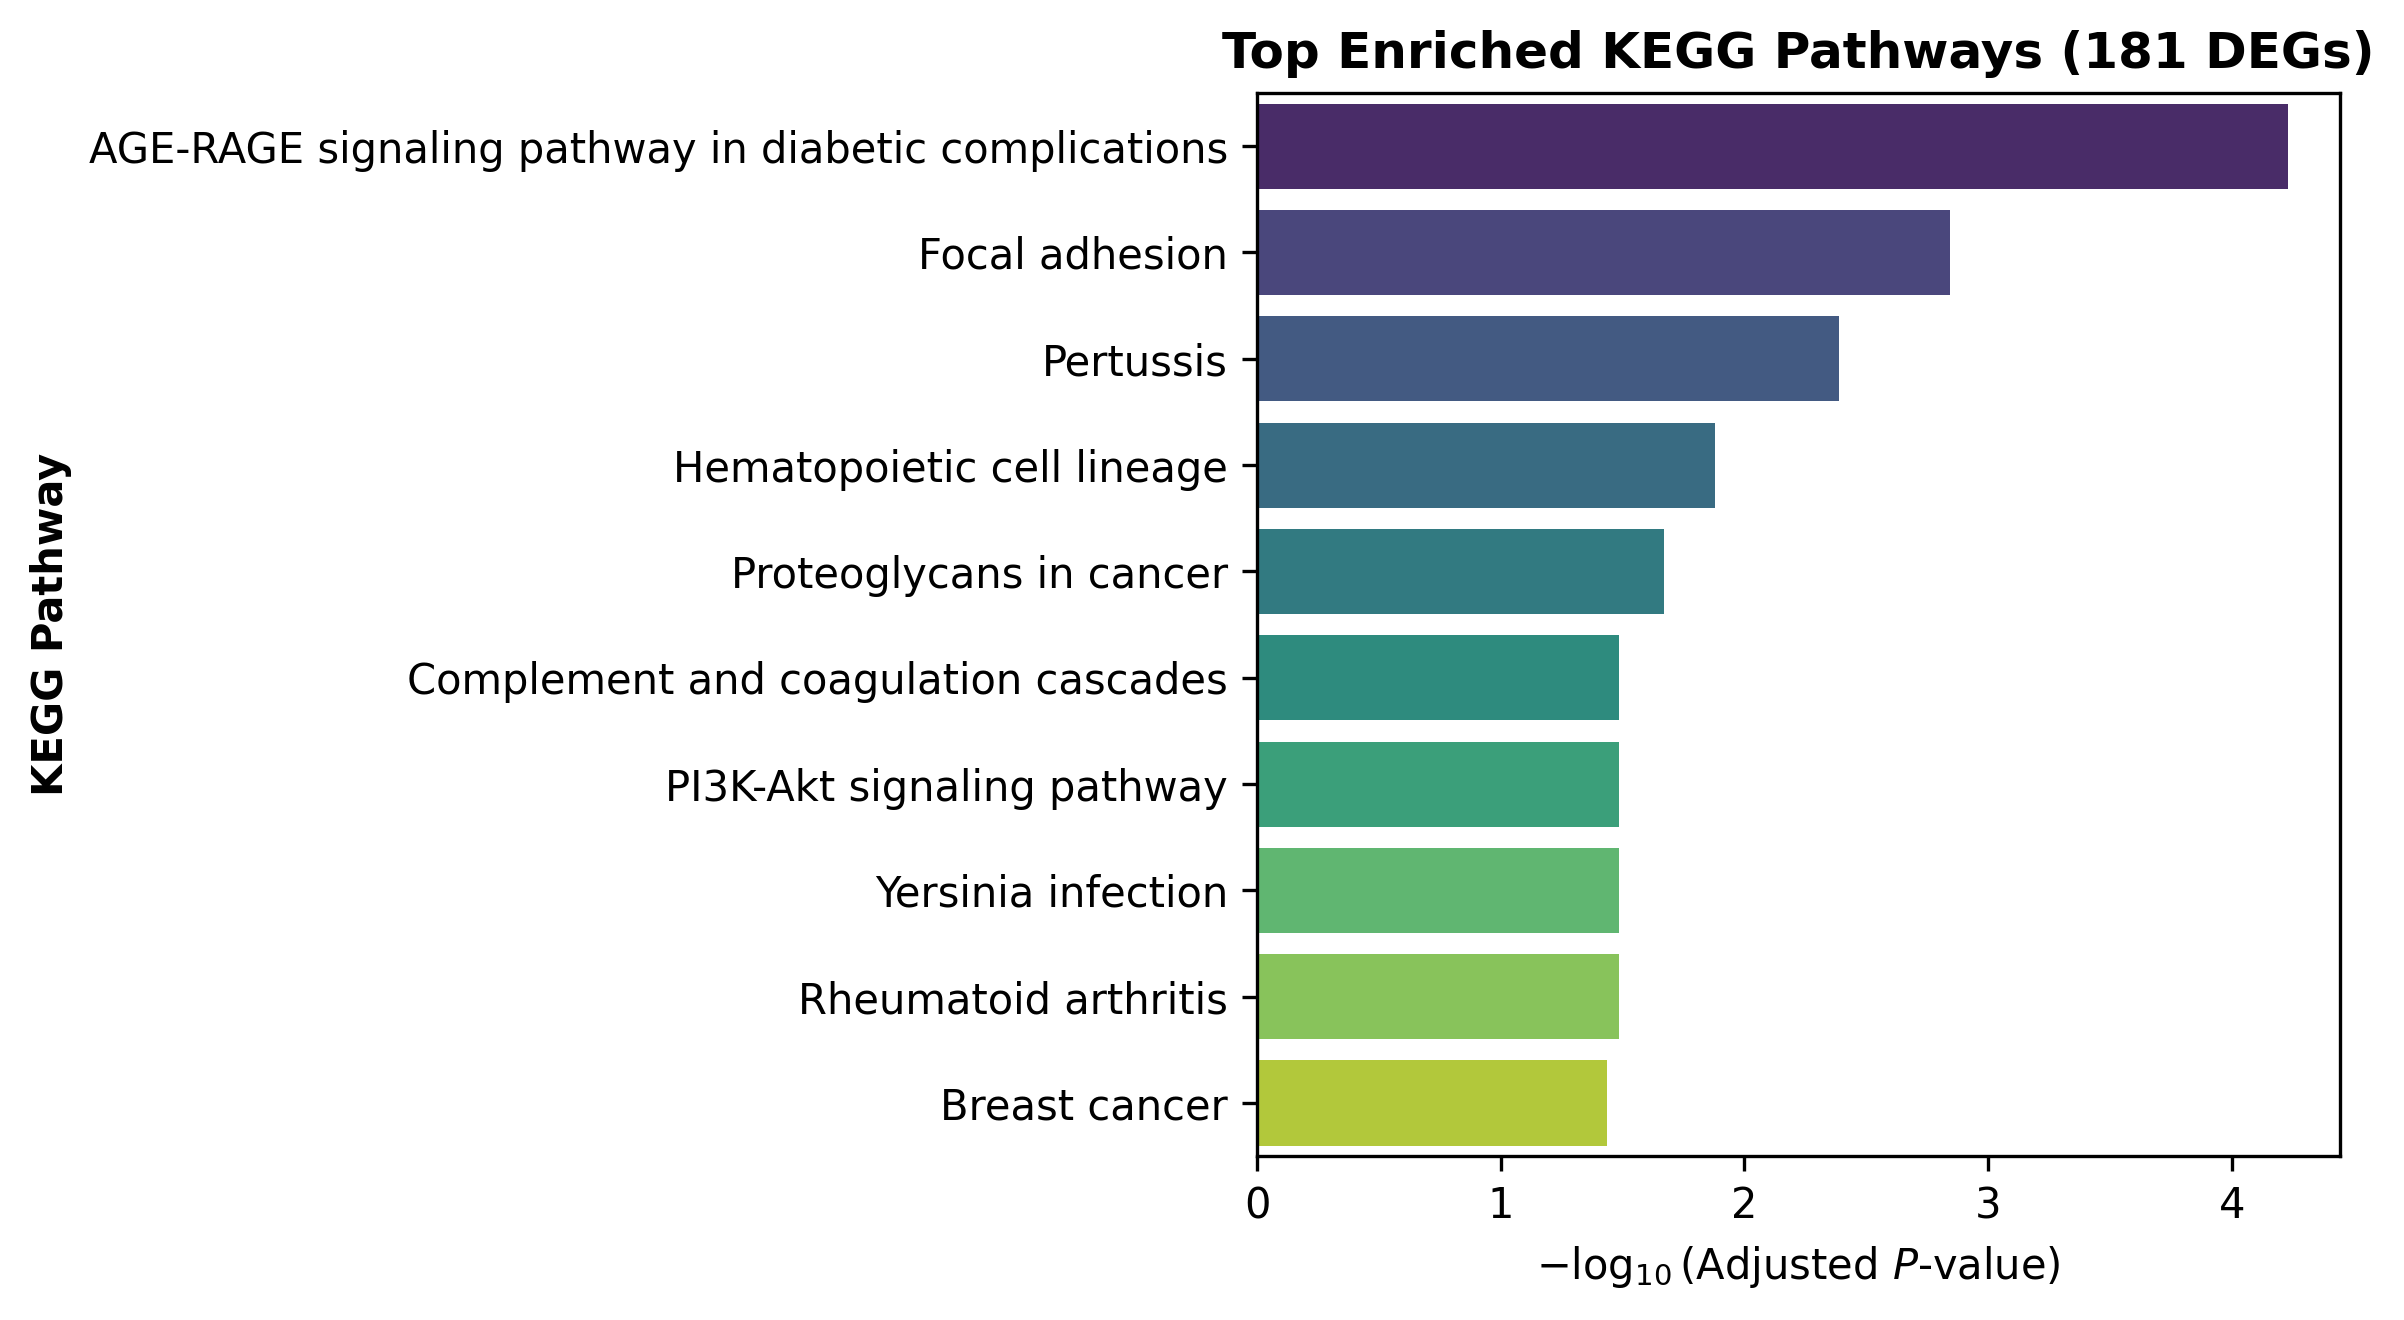


 TOP ENRICHED GO BIOLOGICAL PROCESSES 
                                                      Clean_Term  Adjusted P-value                                                                        Genes
                            extracellular structure organization          0.006982         ITGA3;COL4A4;COL5A3;SMOC1;SERPINE1;MMP3;LAMA3;TEX14;FURIN;ITGA5;FGF2
                             positive regulation of angiogenesis          0.007809                                  IL1A;IL1B;SERPINE1;VEGFC;ITGA5;FGF2;F3;DLL1
                                      regulation of neurogenesis          0.007809                                                HES7;IL6;IL1B;WNT7A;DLL1;TGM2
         positive regulation of multicellular organismal process          0.007809     EPAS1;FST;CAV1;SERPINE1;G0S2;FGF2;IGF1R;CYP27B1;IL1A;IL6;IL1B;ZBED2;SAA1
                   external encapsulating structure organization          0.008782               ITGA3;COL4A4;COL5A3;SMOC1;SERPINE1;MMP3;LAMA3;FURIN;ITGA5;FGF2


/tmp/ipykernel_2148/1605323014.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_go, x='-log10_adj_p', y='Clean_Term', palette='magma', ax=ax)


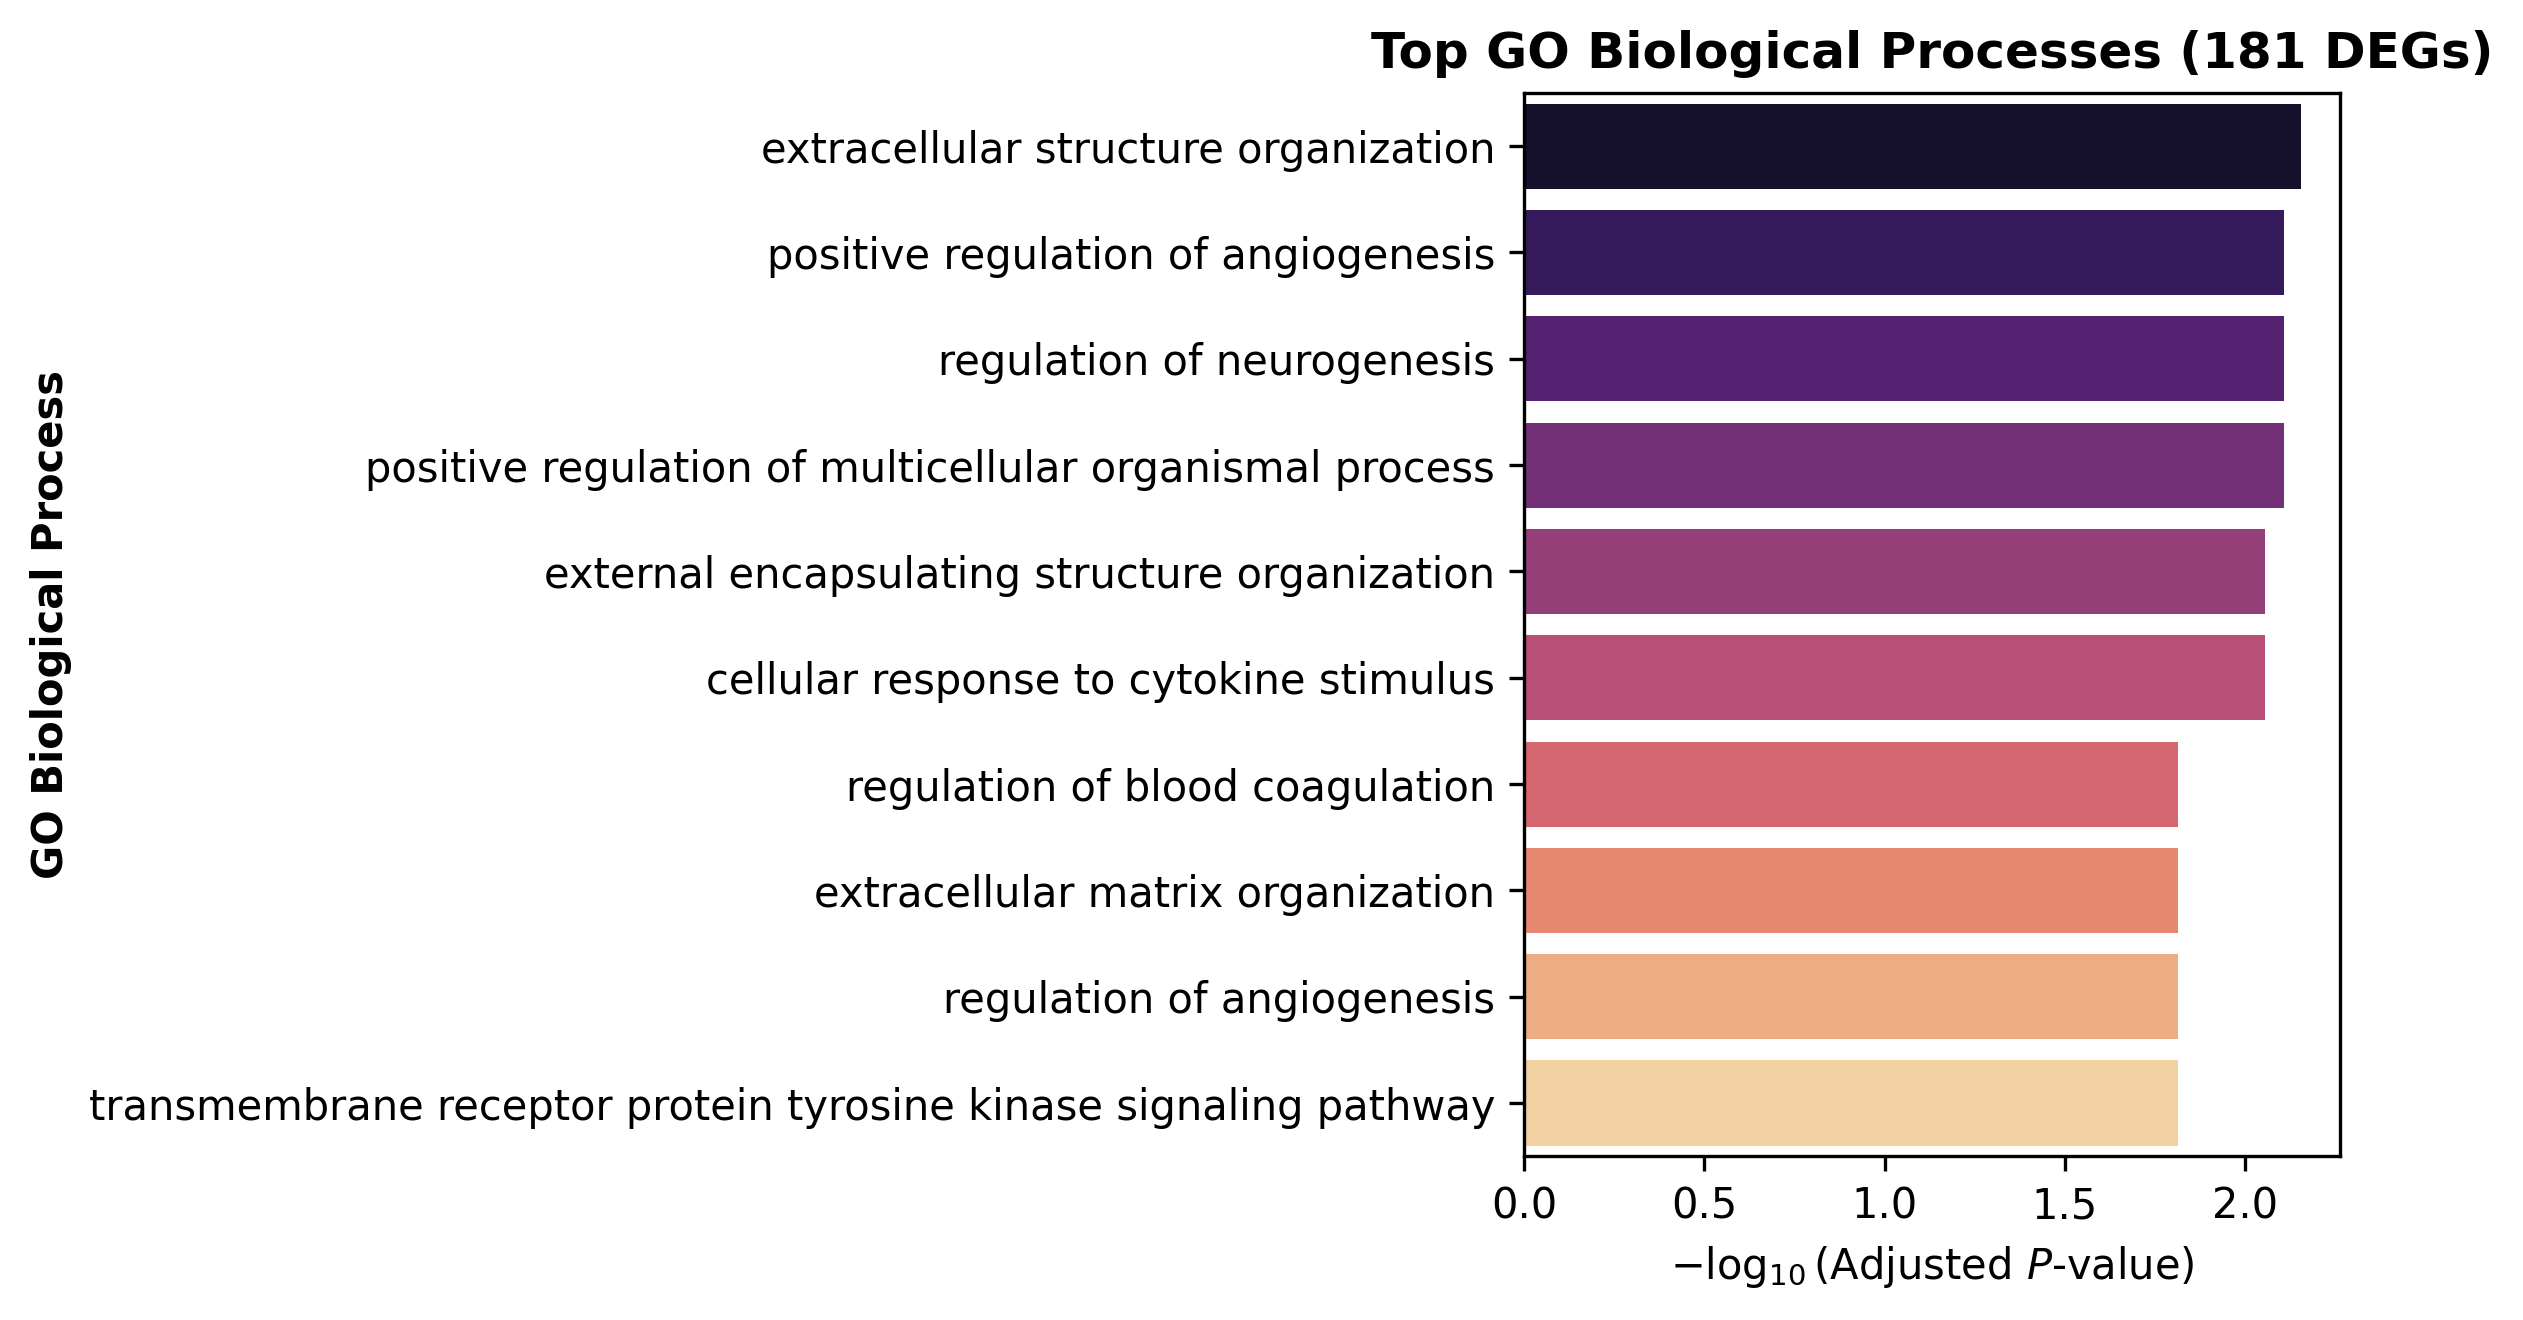

In [ ]:
# Step 7: Perform Pathway Enrichment Analysis via GSEAPy (KEGG and GO)

!pip install -q gseapy

import gseapy as gp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

gene_list = sig_degs['Gene'].dropna().unique().tolist()
print(f"Total DEGs used for Enrichment: {len(gene_list)}")

enr_kegg = gp.enrichr(gene_list=gene_list, gene_sets='KEGG_2021_Human', organism='human', outdir=None)
df_kegg = enr_kegg.results

if not df_kegg.empty:
    df_kegg['Adjusted P-value'] = pd.to_numeric(df_kegg['Adjusted P-value'])
    df_kegg['-log10_adj_p'] = -np.log10(df_kegg['Adjusted P-value'])

    df_kegg['Clean_Term'] = df_kegg['Term'].apply(lambda x: x.split(' Homo')[0])
    top_kegg = df_kegg.sort_values('Adjusted P-value').head(10)

    print("\n TOP ENRICHED KEGG PATHWAYS ")
    print(top_kegg[['Clean_Term', 'Adjusted P-value', 'Genes']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
    sns.barplot(data=top_kegg, x='-log10_adj_p', y='Clean_Term', palette='viridis', ax=ax)
    ax.set_xlabel(r"$-\log_{10}(\text{Adjusted } P\text{-value})$", fontweight='bold')
    ax.set_ylabel("KEGG Pathway", fontweight='bold')
    ax.set_title("Top Enriched KEGG Pathways (181 DEGs)", fontweight='bold')
    plt.tight_layout()
    plt.savefig("Figure2A_KEGG_Real.png", dpi=300)
    plt.show()

enr_go = gp.enrichr(gene_list=gene_list, gene_sets='GO_Biological_Process_2021', organism='human', outdir=None)
df_go = enr_go.results

if not df_go.empty:
    df_go['Adjusted P-value'] = pd.to_numeric(df_go['Adjusted P-value'])
    df_go['-log10_adj_p'] = -np.log10(df_go['Adjusted P-value'])

    df_go['Clean_Term'] = df_go['Term'].apply(lambda x: x.split(' (GO:')[0])
    top_go = df_go.sort_values('Adjusted P-value').head(10)

    print("\n TOP ENRICHED GO BIOLOGICAL PROCESSES ")
    print(top_go[['Clean_Term', 'Adjusted P-value', 'Genes']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
    sns.barplot(data=top_go, x='-log10_adj_p', y='Clean_Term', palette='magma', ax=ax)
    ax.set_xlabel(r"$-\log_{10}(\text{Adjusted } P\text{-value})$", fontweight='bold')
    ax.set_ylabel("GO Biological Process", fontweight='bold')
    ax.set_title("Top GO Biological Processes (181 DEGs)", fontweight='bold')
    plt.tight_layout()
    plt.savefig("Figure2B_GO_Real.png", dpi=300)
    plt.show()

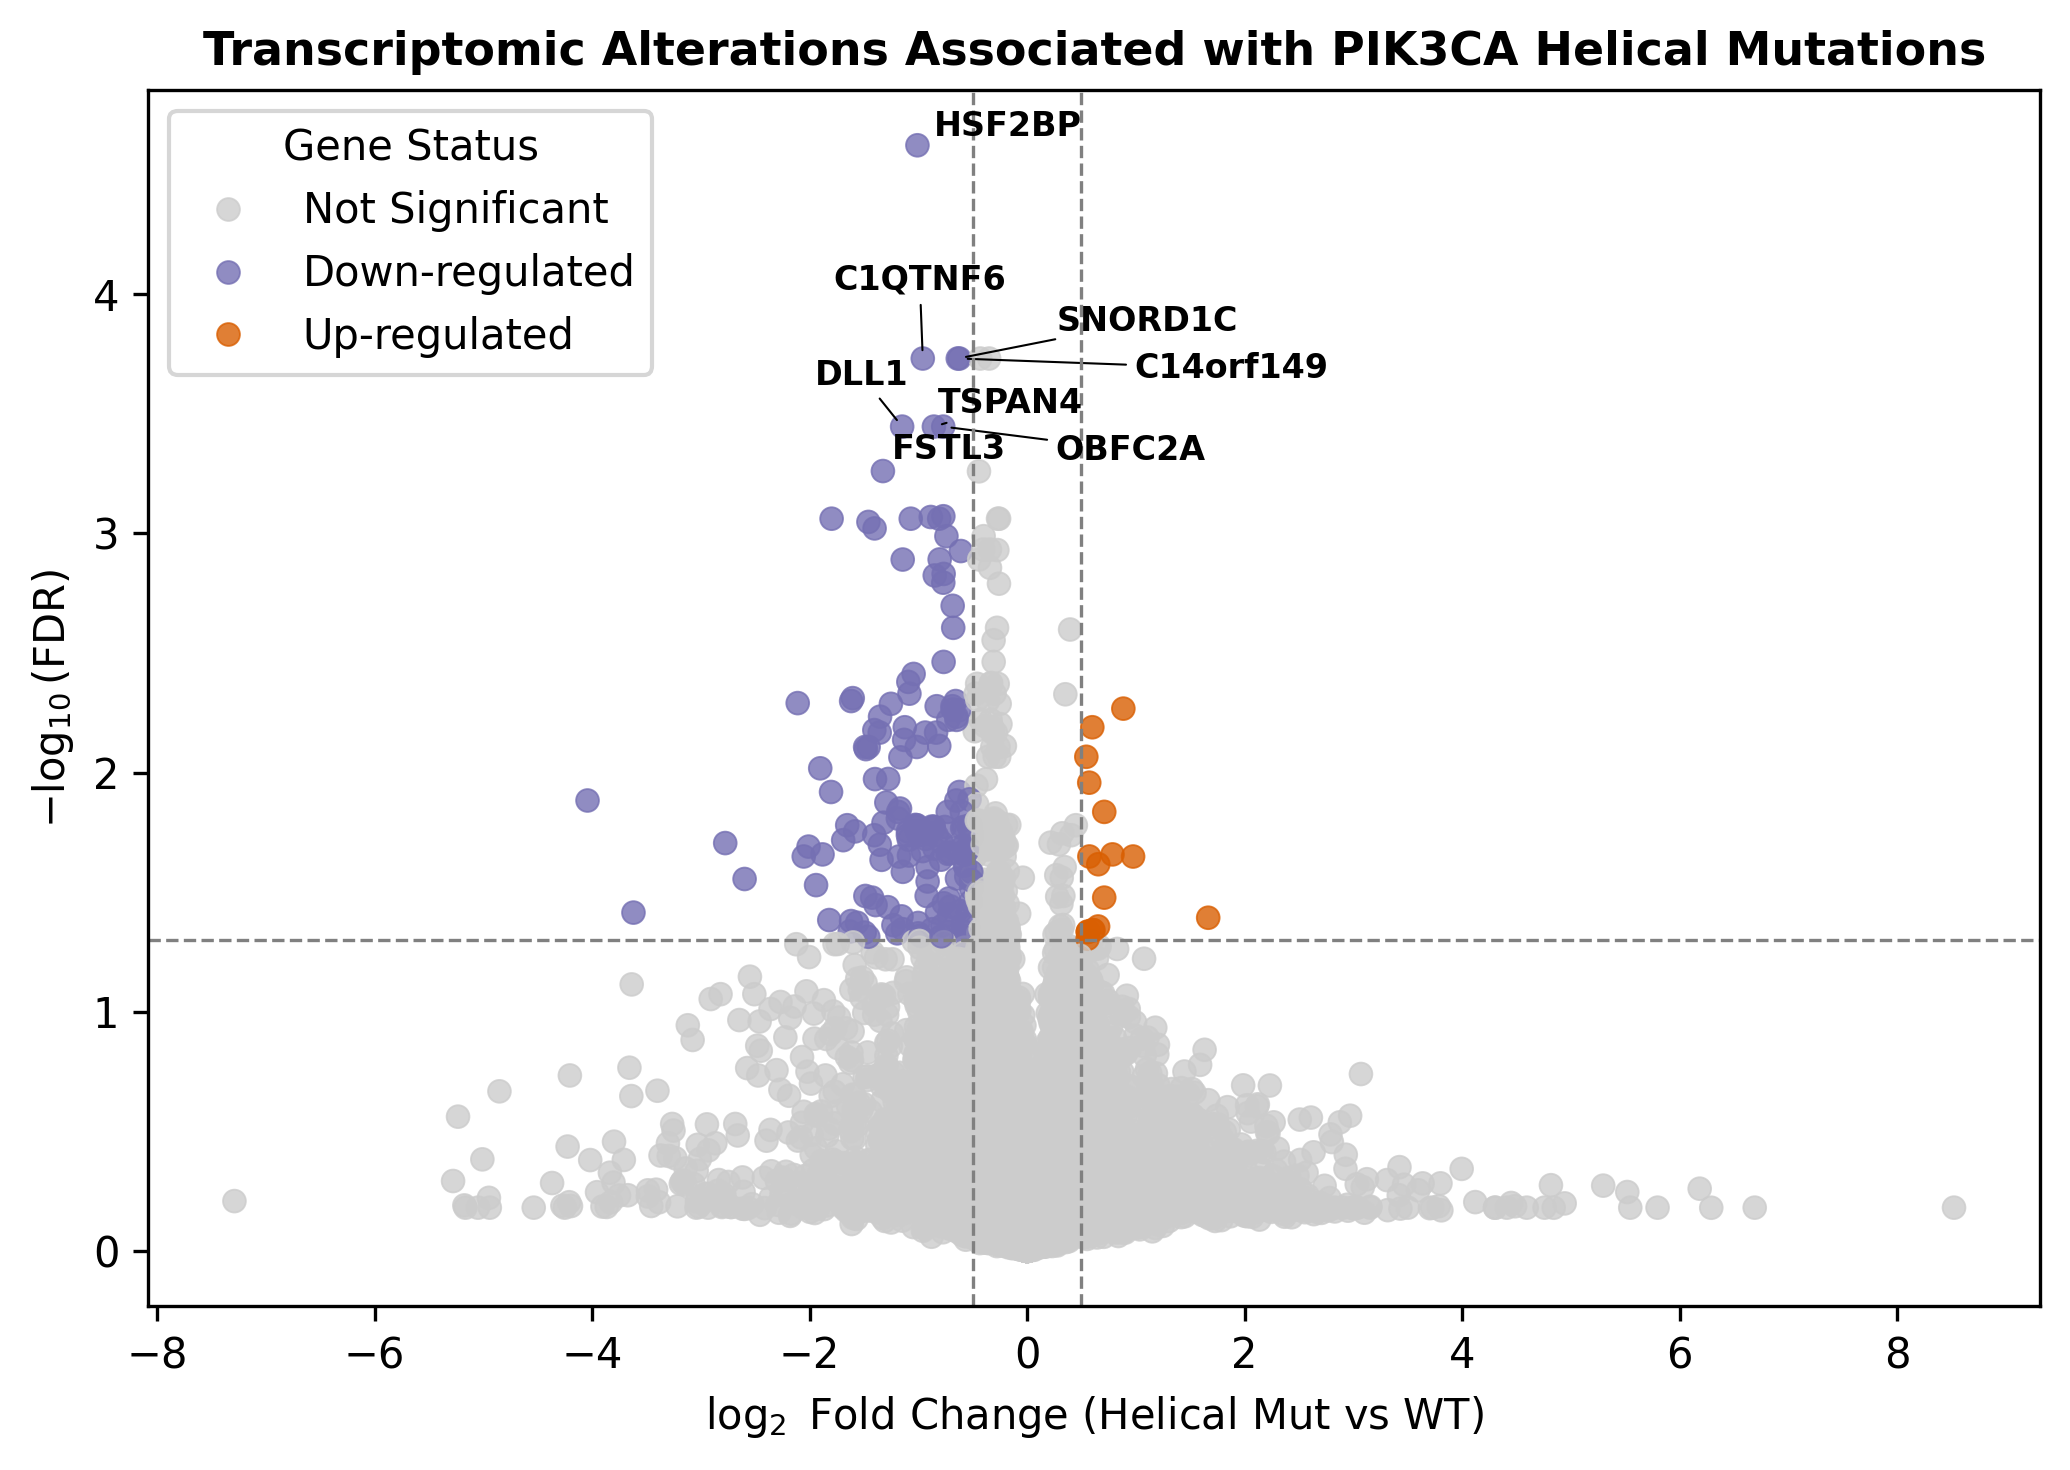

In [ ]:
# Step 8: Generate Volcano Plot for Differentially Expressed Genes (Figure 1B)

!pip install -q adjustText

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
df_dge['-log10_fdr'] = -np.log10(df_dge['FDR'])
palette = {'Up-regulated': '#d95f02', 'Down-regulated': '#7570b3', 'Not Significant': '#cccccc'}

sns.scatterplot(
    data=df_dge, x='Log2FC', y='-log10_fdr', hue='Status',
    palette=palette, alpha=0.8, edgecolor=None, s=30, ax=ax
)

ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(-0.5, color='gray', linestyle='--', linewidth=0.8)

texts = []
top_genes = sig_degs.head(8)['Gene'].values
for gene in top_genes:
    row = df_dge[df_dge['Gene'] == gene].iloc[0]
    texts.append(ax.text(row['Log2FC'], row['-log10_fdr'], gene, fontsize=8, fontweight='bold'))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

ax.set_xlabel(r"$\log_2\text{ Fold Change (Helical Mut vs WT)}$", fontweight='bold')
ax.set_ylabel(r"$-\log_{10}(\text{FDR})$", fontweight='bold')
ax.set_title("Transcriptomic Alterations Associated with PIK3CA Helical Mutations", fontsize=11, fontweight='bold')
ax.legend(title="Gene Status", loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig("Figure1_VolcanoPlot_Clean.png", dpi=300)
plt.show()

In [ ]:
# Step 9: Process Supplementary Table S1 Cohort and Clinical Mapping Dataframe

import pandas as pd
import numpy as np

print("Loading dataset and performing strict overlap matching...")
df_mrna = pd.read_csv('data_mrna_seq_v2_rsem.txt', sep='\t', low_memory=False)
df_mut = pd.read_csv('data_mutations.txt', sep='\t', comment='#', low_memory=False)
df_clin = pd.read_csv('data_clinical_patient.txt', sep='\t', comment='#', low_memory=False)

mrna_samples = [c for c in df_mrna.columns if c.startswith('TCGA-')]
mrna_patients = set([s[:12] for s in mrna_samples])

mut_samples = df_mut['Tumor_Sample_Barcode'].dropna().unique()
mut_patients = set([s[:12] for s in mut_samples])

clin_patients = set(df_clin['PATIENT_ID'].dropna().unique())

overlap_patients = sorted(list(mrna_patients & mut_patients & clin_patients))
print(f"Total Unique Matched Patients (N): {len(overlap_patients)}")

df_mut_filtered = df_mut[df_mut['Tumor_Sample_Barcode'].str.slice(0, 12).isin(overlap_patients)].copy()
df_mut_filtered['Patient_ID'] = df_mut_filtered['Tumor_Sample_Barcode'].str.slice(0, 12)

helical_muts = df_mut_filtered[
    (df_mut_filtered['Hugo_Symbol'] == 'PIK3CA') &
    (df_mut_filtered['HGVSp_Short'].isin(['p.E542K', 'p.E545K']))
]
helical_patients = set(helical_muts['Patient_ID'].unique())
all_pik3ca_mut_patients = set(df_mut_filtered[df_mut_filtered['Hugo_Symbol'] == 'PIK3CA']['Patient_ID'].unique())
wildtype_patients = set(overlap_patients) - all_pik3ca_mut_patients

df_supp1 = pd.DataFrame({'Patient_ID': overlap_patients})

sample_dict = {s[:12]: s for s in mrna_samples}
df_supp1['Sample_ID'] = df_supp1['Patient_ID'].map(sample_dict).fillna(df_supp1['Patient_ID'])

def assign_status(pid):
    if pid in helical_patients:
        return 'Helical Mutated (E542K/E545K)'
    elif pid in wildtype_patients:
        return 'PIK3CA Wild-Type'
    else:
        return 'Excluded Non-helical Outlier'

df_supp1['PIK3CA_Mutation_Status'] = df_supp1['Patient_ID'].apply(assign_status)

pik3ca_only = df_mut_filtered[df_mut_filtered['Hugo_Symbol'] == 'PIK3CA']
hgvsp_map = pik3ca_only.groupby('Patient_ID')['HGVSp_Short'].apply(lambda x: ', '.join(x.dropna().unique())).to_dict()
df_supp1['HGVSp_Short'] = df_supp1['Patient_ID'].map(hgvsp_map).fillna('None (Wild-Type)')

clin_sub = df_clin[['PATIENT_ID', 'AGE', 'SUBTYPE', 'PATH_T_STAGE', 'PATH_N_STAGE', 'PATH_M_STAGE', 'OS_MONTHS', 'OS_STATUS']].copy()
clin_sub = clin_sub.drop_duplicates(subset=['PATIENT_ID'])

clin_sub = clin_sub.rename(columns={
    'PATIENT_ID': 'Patient_ID',
    'AGE': 'Age',
    'SUBTYPE': 'Subtype',
    'PATH_T_STAGE': 'Pathologic_T_Stage',
    'PATH_N_STAGE': 'Pathologic_N_Stage',
    'PATH_M_STAGE': 'Pathologic_M_Stage',
    'OS_MONTHS': 'OS_Months',
    'OS_STATUS': 'OS_Status'
})

df_supp1 = pd.merge(df_supp1, clin_sub, on='Patient_ID', how='left')

df_supp1['Pathologic_T_Stage'] = df_supp1['Pathologic_T_Stage'].fillna('Not Reported')
df_supp1['Pathologic_N_Stage'] = df_supp1['Pathologic_N_Stage'].fillna('Not Reported')
df_supp1['Pathologic_M_Stage'] = df_supp1['Pathologic_M_Stage'].fillna('Not Reported')
df_supp1['Subtype'] = df_supp1['Subtype'].fillna('Not Reported')

print(f"Successfully processed df_supp1 for {len(df_supp1)} patients.")
print(df_supp1['PIK3CA_Mutation_Status'].value_counts())

Loading dataset and performing strict overlap matching...
Total Unique Matched Patients (N): 278
Successfully processed df_supp1 for 278 patients.
PIK3CA_Mutation_Status
PIK3CA Wild-Type                 196
Helical Mutated (E542K/E545K)     58
Excluded Non-helical Outlier      24
Name: count, dtype: int64


--- LIVE CALCULATED MODEL OUTPUTS ---
Hazard Ratio (HR): 0.67
95% CI: [0.34 - 1.32]
p-value: 0.24



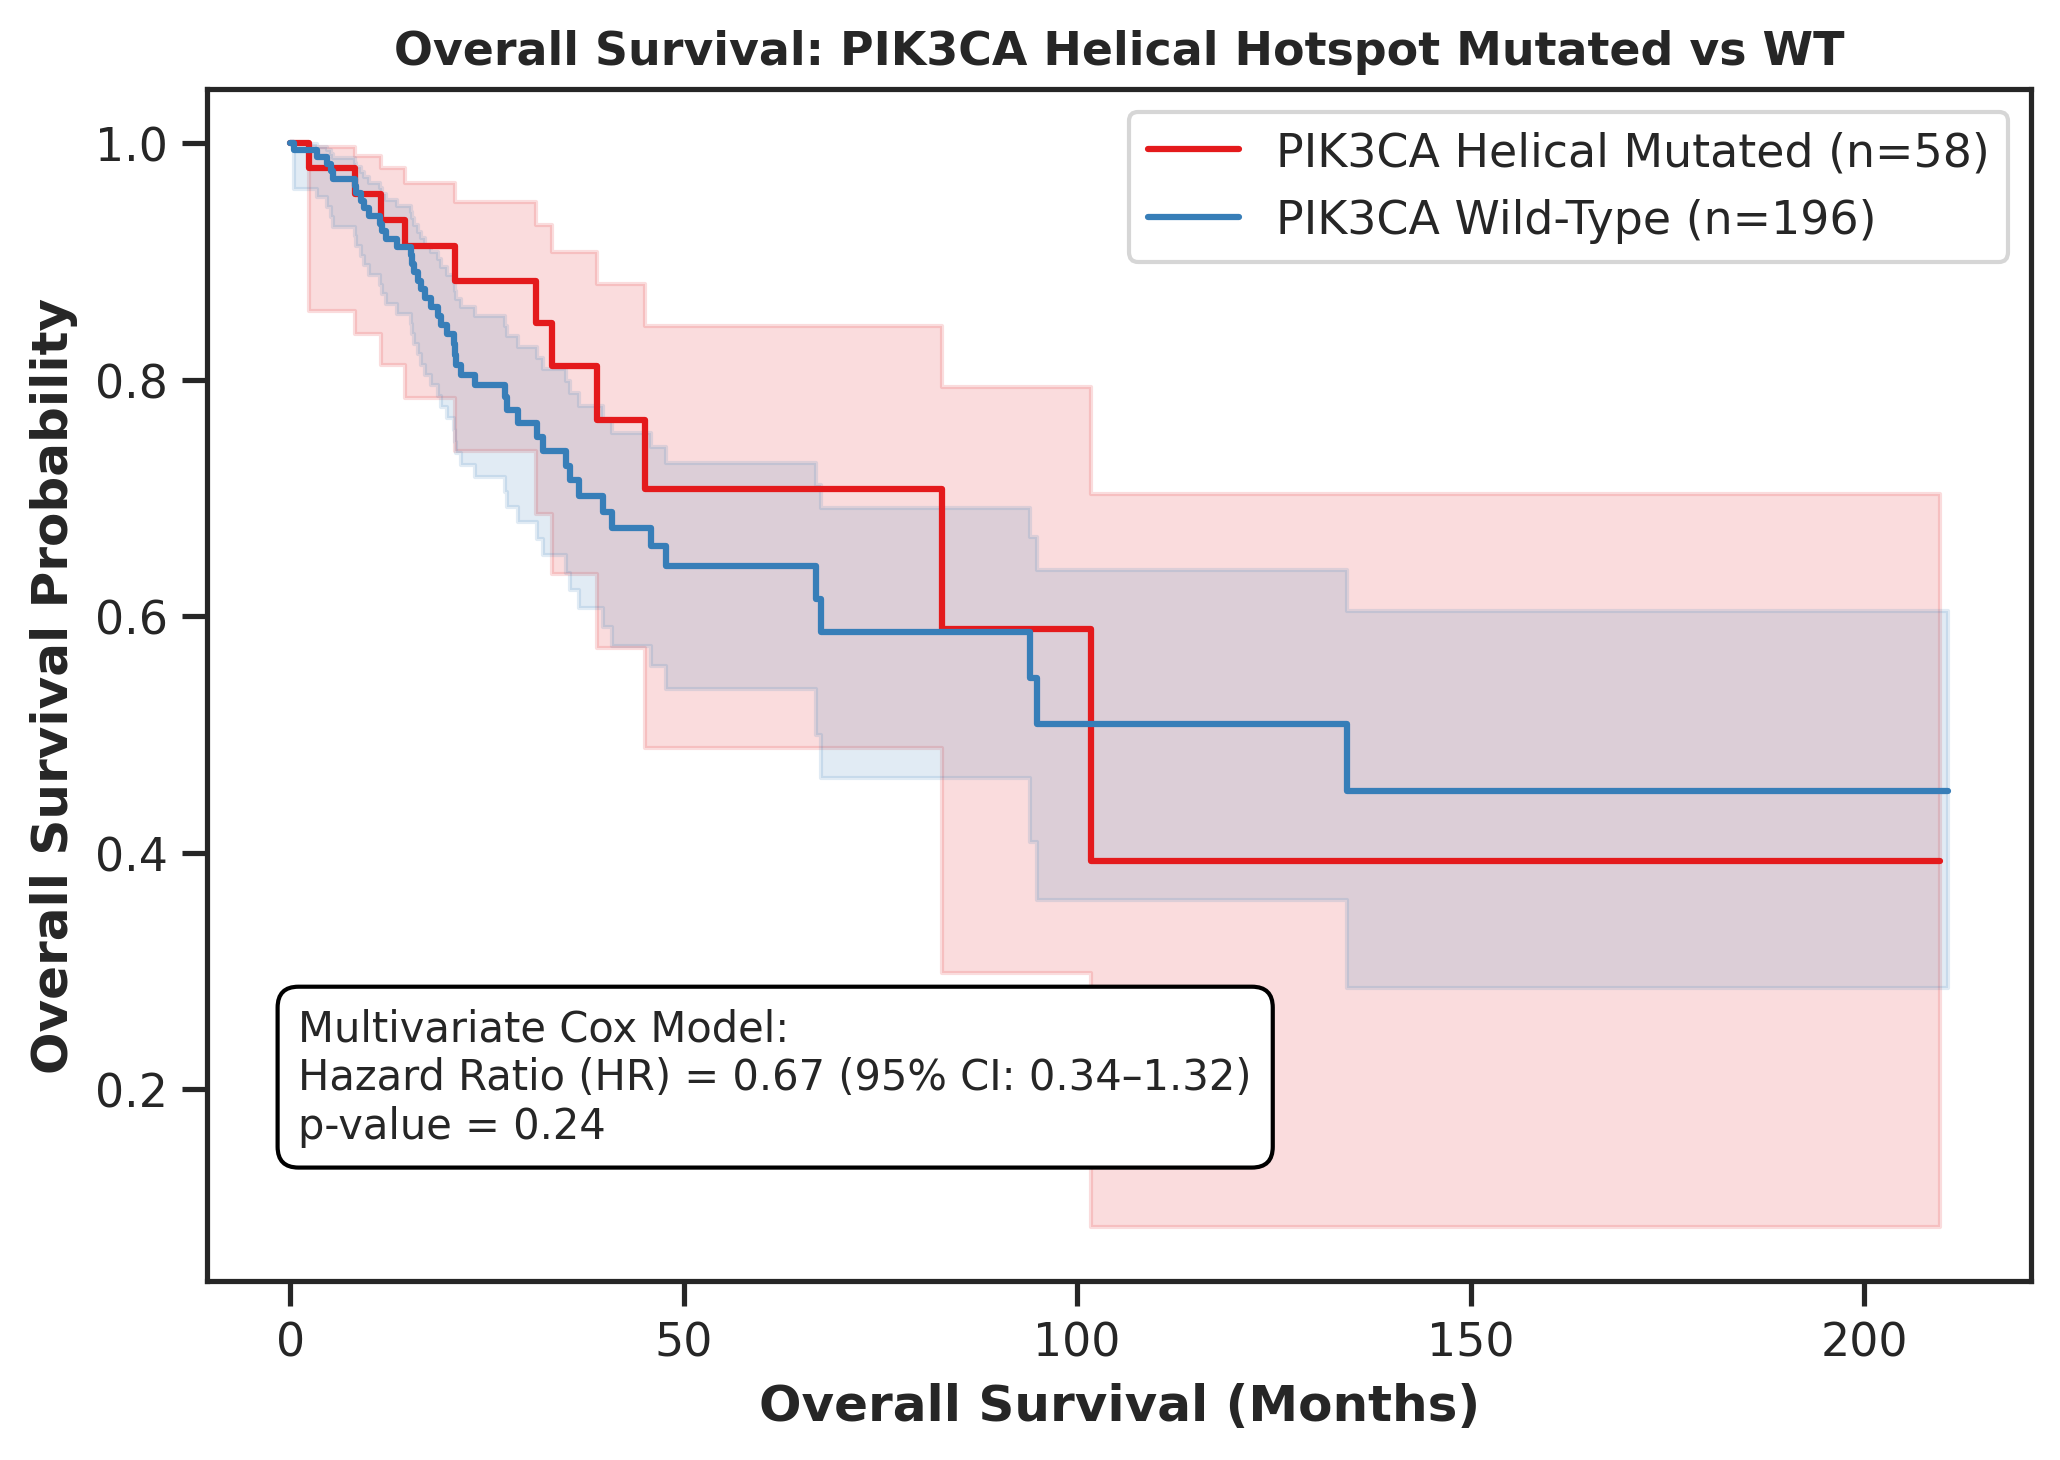


--- MULTIVARIATE COX PH MODEL DETAILS ---
                                   Variable  Coefficient_coef  Hazard_Ratio_exp_coef  SE_coef  95%_CI_Lower  95%_CI_Upper   Z_Score  P_Value
PIK3CA Helical Status (Mutant vs Wild-Type)         -0.405957               0.666339 0.348597      0.336487      1.319538 -1.164543 0.244204
                           Age (Continuous)          0.017034               1.017179 0.010306      0.996839      1.037935  1.652756 0.098381


In [ ]:
# Step 10: Perform Multivariate Cox Model and Plot Kaplan-Meier Survival Curve (Figure 3)

!pip install -q lifelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter

df_cox = df_supp1.dropna(subset=['OS_Months', 'OS_Status']).copy()

df_cox['Event'] = df_cox['OS_Status'].apply(lambda x: 1 if 'DECEASED' in str(x).upper() or '1' in str(x) else 0)
df_cox['OS_Months'] = pd.to_numeric(df_cox['OS_Months'], errors='coerce')

df_cox = df_cox[df_cox['PIK3CA_Mutation_Status'].isin(['Helical Mutated (E542K/E545K)', 'PIK3CA Wild-Type'])].dropna(subset=['OS_Months', 'Age']).copy()

df_cox['Is_Helical'] = (df_cox['PIK3CA_Mutation_Status'] == 'Helical Mutated (E542K/E545K)').astype(int)
df_cox['Age'] = pd.to_numeric(df_cox['Age'], errors='coerce')

cph = CoxPHFitter()
cph.fit(df_cox[['OS_Months', 'Event', 'Is_Helical', 'Age']], duration_col='OS_Months', event_col='Event')

summary_df = cph.summary
hr_val = summary_df.loc['Is_Helical', 'exp(coef)']
ci_lower = summary_df.loc['Is_Helical', 'exp(coef) lower 95%']
ci_upper = summary_df.loc['Is_Helical', 'exp(coef) upper 95%']
p_val = summary_df.loc['Is_Helical', 'p']

print("--- LIVE CALCULATED MODEL OUTPUTS ---")
print(f"Hazard Ratio (HR): {hr_val:.2f}")
print(f"95% CI: [{ci_lower:.2f} - {ci_upper:.2f}]")
print(f"p-value: {p_val:.2f}\n")

sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams.update({'font.size': 11, 'pdf.fonttype': 42, 'ps.fonttype': 42})

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
kmf = KaplanMeierFitter()

mask_helical = (df_cox['Is_Helical'] == 1)
n_helical = mask_helical.sum()
kmf.fit(df_cox[mask_helical]['OS_Months'], df_cox[mask_helical]['Event'], label=f'PIK3CA Helical Mutated (n={n_helical})')
kmf.plot_survival_function(ax=ax, color='#e41a1c', ci_alpha=0.15)

n_wt = (~mask_helical).sum()
kmf.fit(df_cox[~mask_helical]['OS_Months'], df_cox[~mask_helical]['Event'], label=f'PIK3CA Wild-Type (n={n_wt})')
kmf.plot_survival_function(ax=ax, color='#377eb8', ci_alpha=0.15)

stats_text = (f"Multivariate Cox Model:\n"
              f"Hazard Ratio (HR) = {hr_val:.2f} (95% CI: {ci_lower:.2f}–{ci_upper:.2f})\n"
              f"p-value = {p_val:.2f}")

ax.text(0.05, 0.12, stats_text, transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"))

ax.set_xlabel("Overall Survival (Months)", fontweight='bold')
ax.set_ylabel("Overall Survival Probability", fontweight='bold')
ax.set_title("Overall Survival: PIK3CA Helical Hotspot Mutated vs WT", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure3_Survival_Live_Model.png", dpi=300)
plt.show()

df_supp4 = summary_df.reset_index()[['covariate', 'coef', 'exp(coef)', 'se(coef)',
                                    'exp(coef) lower 95%', 'exp(coef) upper 95%', 'z', 'p']]

df_supp4.columns = [
    'Variable',
    'Coefficient_coef',
    'Hazard_Ratio_exp_coef',
    'SE_coef',
    '95%_CI_Lower',
    '95%_CI_Upper',
    'Z_Score',
    'P_Value'
]

df_supp4['Variable'] = df_supp4['Variable'].replace({
    'Is_Helical': 'PIK3CA Helical Status (Mutant vs Wild-Type)',
    'Age': 'Age (Continuous)'
})

print("\n--- MULTIVARIATE COX PH MODEL DETAILS ---")
print(df_supp4.to_string(index=False))

/tmp/ipykernel_2148/191801115.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


--- DYNAMIC VALIDATION FROM RAW FILES ---
Helical Mutated Mean RSEM: 529.89 (n=58)
Wild-Type Mean RSEM: 545.93 (n=196)
Calculated Welch's t-test p-value: 0.7091



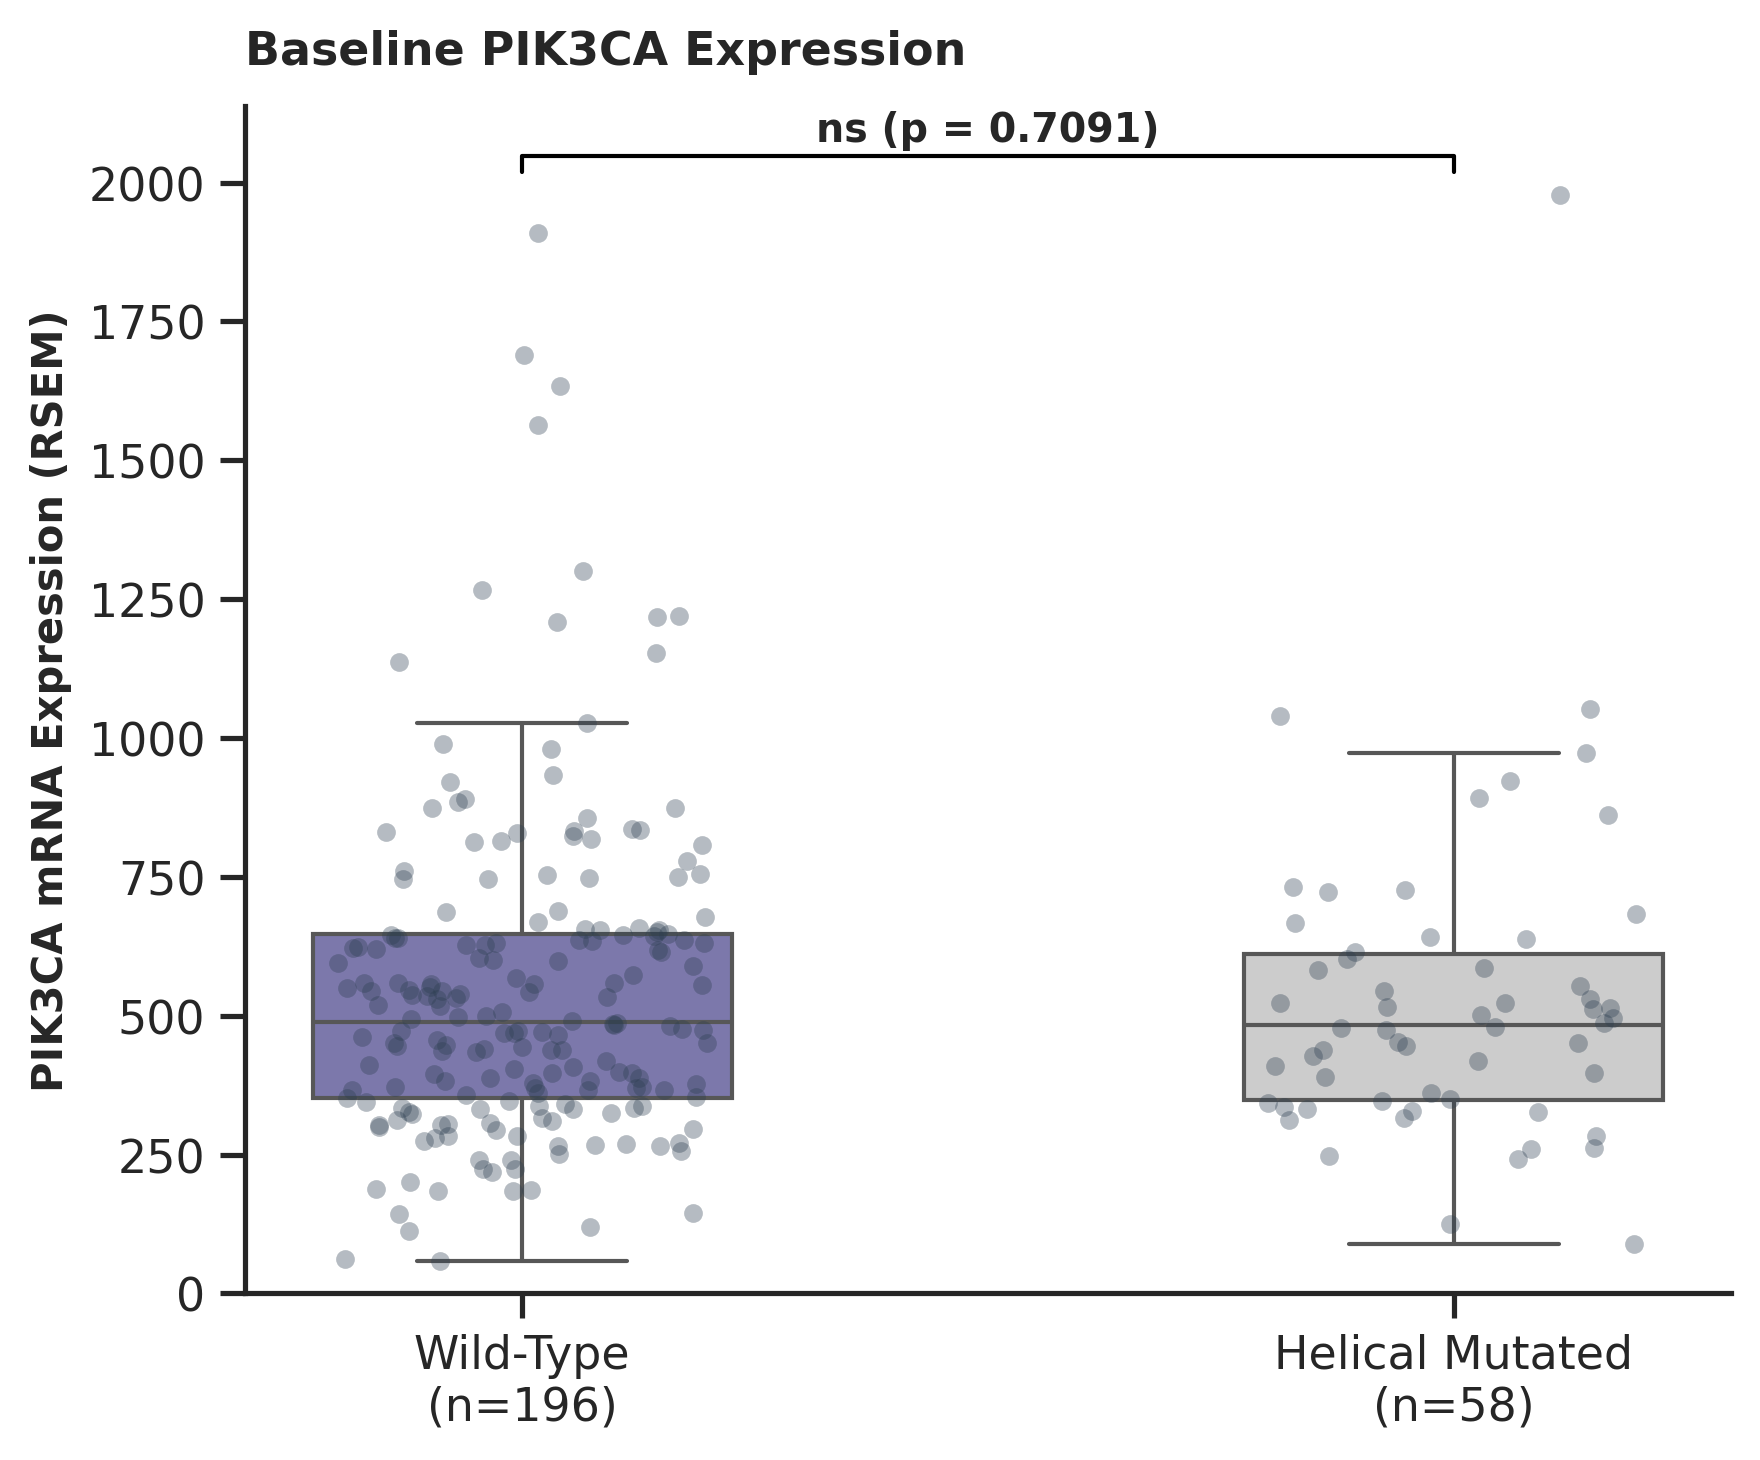

In [ ]:
# Step 11: Generate Standalone Figure 1A (Baseline PIK3CA Expression Boxplot)

try:
    import google.colab
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 300


df_mut = pd.read_csv("data_mutations.txt", sep="\t", comment="#", low_memory=False)
df_mrna = pd.read_csv("data_mrna_seq_v2_rsem.txt", sep="\t", comment="#")

if "Patient_ID" not in df_mut.columns:
    df_mut["Patient_ID"] = df_mut["Tumor_Sample_Barcode"].str[:12]

mrna_samples = [c for c in df_mrna.columns if c not in ["Hugo_Symbol", "Entrez_Gene_Id"]]
sample_to_patient = {s: s[:12] for sstr in [mrna_samples] for s in sstr}
patient_to_samples = {v: k for k, v in sample_to_patient.items()}

mut_patients = set(df_mut["Patient_ID"])
mrna_patients = set(sample_to_patient.values())
common_patients = sorted(list(mut_patients.intersection(mrna_patients)))

df_mut_filtered = df_mut[df_mut["Patient_ID"].isin(common_patients)].copy()

pik3ca_mut_patients = set(df_mut_filtered[df_mut_filtered["Hugo_Symbol"] == "PIK3CA"]["Patient_ID"])
helical_hotspots = ["p.E542K", "p.E545K"]
helical_mut_patients = set(
    df_mut_filtered[
        (df_mut_filtered["Hugo_Symbol"] == "PIK3CA")
        & (df_mut_filtered["HGVSp_Short"].isin(helical_hotspots))
    ]["Patient_ID"]
)

wildtype_patients = set(common_patients) - pik3ca_mut_patients

group_dict = {}
for p in helical_mut_patients:
    group_dict[p] = "Helical Mutated\n(n=58)"
for p in wildtype_patients:
    group_dict[p] = "Wild-Type\n(n=196)"


pik3ca_row = df_mrna[df_mrna["Hugo_Symbol"] == "PIK3CA"].iloc[0]

data_list = []
for p in common_patients:
    if p in group_dict:
        sample_id = patient_to_samples[p]
        exp_val = float(pik3ca_row[sample_id])
        data_list.append(
            {
                "Patient_ID": p,
                "Group": group_dict[p],
                "PIK3CA_RSEM": exp_val,
            }
        )

df_box_dynamic = pd.DataFrame(data_list)

helical_exp = df_box_dynamic[df_box_dynamic["Group"].str.contains("Helical Mutated")]["PIK3CA_RSEM"]
wt_exp = df_box_dynamic[df_box_dynamic["Group"].str.contains("Wild-Type")]["PIK3CA_RSEM"]

t_stat, p_val_calculated = stats.ttest_ind(helical_exp, wt_exp, equal_var=False)

print("--- DYNAMIC VALIDATION FROM RAW FILES ---")
print(f"Helical Mutated Mean RSEM: {helical_exp.mean():.2f} (n={len(helical_exp)})")
print(f"Wild-Type Mean RSEM: {wt_exp.mean():.2f} (n={len(wt_exp)})")
print(f"Calculated Welch's t-test p-value: {p_val_calculated:.4f}\n")


fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

sns.boxplot(
    x="Group",
    y="PIK3CA_RSEM",
    data=df_box_dynamic,
    ax=ax,
    palette=["#7570b3", "#cccccc"],
    width=0.45,
    fliersize=0,
)

sns.stripplot(
    x="Group",
    y="PIK3CA_RSEM",
    data=df_box_dynamic,
    ax=ax,
    color="#2c3e50",
    alpha=0.35,
    jitter=0.2,
    size=4.5,
)

y_max = df_box_dynamic["PIK3CA_RSEM"].max() + 40
ax.plot([0, 0, 1, 1], [y_max, y_max + 30, y_max + 30, y_max], color="black", lw=1)

p_text = (
    f"ns (p = {p_val_calculated:.4f})"
    if p_val_calculated > 0.05
    else f"p = {p_val_calculated:.4f}"
)
ax.text(
    0.5,
    y_max + 40,
    p_text,
    ha="center",
    va="bottom",
    fontsize=9.5,
    fontweight="bold",
)

ax.set_title(
    "Baseline PIK3CA Expression",
    fontsize=11,
    fontweight="bold",
    pad=10,
    loc="left",
)
ax.set_ylabel("PIK3CA mRNA Expression (RSEM)", fontsize=10, fontweight="bold")
ax.set_xlabel("")
ax.set_ylim(0, y_max + 120)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("Figure_1A_Baseline_PIK3CA_Expression.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Cohort mapping of 278 unique patients with clinical metadata and PIK3CA mutation status

import pandas as pd
import numpy as np

df_mrna = pd.read_csv('data_mrna_seq_v2_rsem.txt', sep='\t', low_memory=False)
df_mut = pd.read_csv('data_mutations.txt', sep='\t', comment='#', low_memory=False)
df_clin = pd.read_csv('data_clinical_patient.txt', sep='\t', comment='#', low_memory=False)

mrna_samples = [c for c in df_mrna.columns if c.startswith('TCGA-')]
mrna_patients = set([s[:12] for s in mrna_samples])

mut_samples = df_mut['Tumor_Sample_Barcode'].dropna().unique()
mut_patients = set([s[:12] for s in mut_samples])

clin_patients = set(df_clin['PATIENT_ID'].dropna().unique())

overlap_patients = sorted(list(mrna_patients & mut_patients & clin_patients))

df_mut_filtered = df_mut[df_mut['Tumor_Sample_Barcode'].str.slice(0, 12).isin(overlap_patients)].copy()
df_mut_filtered['Patient_ID'] = df_mut_filtered['Tumor_Sample_Barcode'].str.slice(0, 12)

helical_muts = df_mut_filtered[
    (df_mut_filtered['Hugo_Symbol'] == 'PIK3CA') &
    (df_mut_filtered['HGVSp_Short'].isin(['p.E542K', 'p.E545K']))
]
helical_patients = set(helical_muts['Patient_ID'].unique())
all_pik3ca_mut_patients = set(df_mut_filtered[df_mut_filtered['Hugo_Symbol'] == 'PIK3CA']['Patient_ID'].unique())
wildtype_patients = set(overlap_patients) - all_pik3ca_mut_patients

df_supp1 = pd.DataFrame({'Patient_ID': overlap_patients})

sample_dict = {s[:12]: s for s in mrna_samples}
df_supp1['Sample_ID'] = df_supp1['Patient_ID'].map(sample_dict).fillna(df_supp1['Patient_ID'])

def assign_status(pid):
    if pid in helical_patients:
        return 'Helical Mutated (E542K/E545K)'
    elif pid in wildtype_patients:
        return 'PIK3CA Wild-Type'
    else:
        return 'Excluded Non-helical Outlier'

df_supp1['PIK3CA_Mutation_Status'] = df_supp1['Patient_ID'].apply(assign_status)

pik3ca_only = df_mut_filtered[df_mut_filtered['Hugo_Symbol'] == 'PIK3CA']
hgvsp_map = pik3ca_only.groupby('Patient_ID')['HGVSp_Short'].apply(lambda x: ', '.join(x.dropna().unique())).to_dict()
df_supp1['HGVSp_Short'] = df_supp1['Patient_ID'].map(hgvsp_map).fillna('None (Wild-Type)')

clin_sub = df_clin[['PATIENT_ID', 'AGE', 'SUBTYPE', 'PATH_T_STAGE', 'PATH_N_STAGE', 'PATH_M_STAGE', 'OS_MONTHS', 'OS_STATUS']].copy()
clin_sub = clin_sub.drop_duplicates(subset=['PATIENT_ID'])

clin_sub = clin_sub.rename(columns={
    'PATIENT_ID': 'Patient_ID',
    'AGE': 'Age',
    'SUBTYPE': 'Subtype',
    'PATH_T_STAGE': 'Pathologic_T_Stage',
    'PATH_N_STAGE': 'Pathologic_N_Stage',
    'PATH_M_STAGE': 'Pathologic_M_Stage',
    'OS_MONTHS': 'OS_Months',
    'OS_STATUS': 'OS_Status'
})

df_supp1 = pd.merge(df_supp1, clin_sub, on='Patient_ID', how='left')

df_supp1['Pathologic_T_Stage'] = df_supp1['Pathologic_T_Stage'].fillna('Not Reported')
df_supp1['Pathologic_N_Stage'] = df_supp1['Pathologic_N_Stage'].fillna('Not Reported')
df_supp1['Pathologic_M_Stage'] = df_supp1['Pathologic_M_Stage'].fillna('Not Reported')
df_supp1['Subtype'] = df_supp1['Subtype'].fillna('Not Reported')

df_supp1.to_excel('Supplementary_Table_S1_Cohort_Mapping.xlsx', index=False)

In [ ]:
# Differential gene expression analysis between PIK3CA helical mutated and wild-type cohorts

import pandas as pd
import numpy as np
from scipy import stats

df_mrna = pd.read_csv('data_mrna_seq_v2_rsem.txt', sep='\t', low_memory=False)

gene_col = 'Hugo_Symbol' if 'Hugo_Symbol' in df_mrna.columns else df_mrna.columns[0]
sample_cols = [c for c in df_mrna.columns if c.startswith('TCGA-')]

helical_samples = [s for s in sample_cols if s[:12] in helical_patients]
wt_samples = [s for s in sample_cols if s[:12] in wildtype_patients]

dge_results = []

exp_helical = df_mrna[helical_samples].values
exp_wt = df_mrna[wt_samples].values
gene_symbols = df_mrna[gene_col].values

for i in range(len(df_mrna)):
    gene = gene_symbols[i]
    if pd.isna(gene):
        continue

    val_h = exp_helical[i, :]
    val_wt = exp_wt[i, :]

    val_h = val_h[~np.isnan(val_h)]
    val_wt = val_wt[~np.isnan(val_wt)]

    if len(val_h) < 3 or len(val_wt) < 3:
        continue

    mean_h = np.mean(val_h)
    mean_wt = np.mean(val_wt)

    log2fc = np.log2(mean_h + 1) - np.log2(mean_wt + 1)

    _, pval = stats.ttest_ind(val_h, val_wt, equal_var=False)

    if np.isnan(pval):
        pval = 1.0

    dge_results.append({
        'Gene_Symbol': gene,
        'Log2_Fold_Change': log2fc,
        'P_Value': pval
    })

df_supp2 = pd.DataFrame(dge_results)

df_supp2 = df_supp2.sort_values('P_Value').reset_index(drop=True)
n_tests = len(df_supp2)
df_supp2['Adjusted_P_Value'] = df_supp2['P_Value'] * n_tests / (df_supp2.index + 1)
df_supp2['Adjusted_P_Value'] = np.minimum.accumulate(df_supp2['Adjusted_P_Value'][::-1])[::-1]
df_supp2['Adjusted_P_Value'] = np.clip(df_supp2['Adjusted_P_Value'], 0, 1.0)

def set_regulation(row):
    if row['P_Value'] < 0.05:
        if row['Log2_Fold_Change'] >= 0.585:
            return 'Up-regulated'
        elif row['Log2_Fold_Change'] <= -0.585:
            return 'Down-regulated'
    return 'Not Significant'

df_supp2['Regulation_Status'] = df_supp2.apply(set_regulation, axis=1)

df_supp2.to_excel('Supplementary_Table_S2_DGE_Results.xlsx', index=False)

In [ ]:
# Extraction and export of 181 statistically significant differentially expressed genes

import pandas as pd

df_sig_181 = df_dge[df_dge['Status'].isin(['Up-regulated', 'Down-regulated'])].copy()

df_sig_181['Abs_Log2FC'] = df_sig_181['Log2FC'].abs()
df_sig_181 = df_sig_181.sort_values(by=['FDR', 'Abs_Log2FC'], ascending=[True, False]).drop(columns=['Abs_Log2FC'])

df_sig_181.to_excel('Supplementary_Table_S3_Significant_181_DEGs_List.xlsx', index=False)

In [12]:
# Functional enrichment analysis using Enrichr API for GO terms and KEGG pathways

import pandas as pd
import requests
import json

deg_genes = sig_degs['Gene'].dropna().unique().tolist()

ENRICHR_URL = 'https://maayanlab.cloud/Enrichr/addList'
genes_str = '\n'.join(deg_genes)
payload = {
    'list': (None, genes_str),
    'description': (None, 'TCGA-CESC Helical Mutants DEGs')
}

response = requests.post(ENRICHR_URL, files=payload)
if not response.ok:
    raise Exception('Enrichr API connection error')

data = json.loads(response.text)
user_list_id = data['userListId']

gene_sets = [
    'GO_Biological_Process_2021',
    'GO_Cellular_Component_2021',
    'GO_Molecular_Function_2021',
    'KEGG_2021_Human'
]

enrichment_results = []

for gset in gene_sets:
    results_url = f'https://maayanlab.cloud/Enrichr/enrich?userListId={user_list_id}&backgroundType={gset}'
    res = requests.get(results_url)
    if not res.ok:
        continue

    res_data = json.loads(res.text)[gset]
    cat_name = 'KEGG Pathway' if 'KEGG' in gset else gset.replace('_2021', '').replace('_', ' ')

    for item in res_data:
        p_val = item[2]
        adj_p_val = item[6]
        genes_list = ', '.join(item[5])
        gene_count = len(item[5])

        if adj_p_val < 0.05:
            enrichment_results.append({
                'Category': cat_name,
                'Term': item[1],
                'Gene_Count': gene_count,
                'P_Value': p_val,
                'Adjusted_P_Value': adj_p_val,
                'Target_Genes': genes_list
            })

df_supp4 = pd.DataFrame(enrichment_results)

if not df_supp4.empty:
    df_supp4 = df_supp4.sort_values(by=['Category', 'Adjusted_P_Value'], ascending=[True, True])

df_supp4.to_excel('Supplementary_Table_S4_Functional_Enrichment.xlsx', index=False)